# Mode Dynamics Walkthrough

Goal: train a small network on `y = sin(x)` and check whether learning dynamics collapse into a low-dimensional set of update modes.

## 1) Imports and setup

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import torch

from mode_dynamics import (
    SineMLP,
    build_sine_dataset,
    train_with_tracking,
)

np.random.seed(0)
torch.manual_seed(0)

## 2) Dataset

In [10]:
n_samples = 5000
x_train, y_train = build_sine_dataset(
    n_samples=n_samples,
    seed=0,
)

print('Train:', x_train.shape, y_train.shape)

Train: torch.Size([5000, 1]) torch.Size([5000, 1])


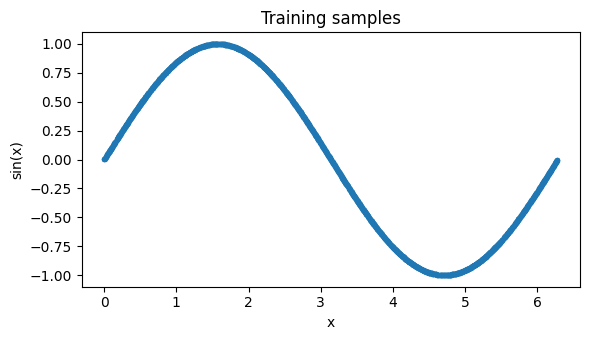

In [11]:
plt.figure(figsize=(6, 3.5))
plt.scatter(x_train.numpy(), y_train.numpy(), s=8, alpha=0.45)
plt.xlabel('x')
plt.ylabel('sin(x)')
plt.title('Training samples')
plt.tight_layout()
plt.show()

## 3) Model

In [12]:
hidden_dim = 2
model = SineMLP(hidden_dim=hidden_dim)
print(model)
print('Total params:', sum(p.numel() for p in model.parameters()))

SineMLP(
  (net): Sequential(
    (0): Linear(in_features=1, out_features=2, bias=True)
    (1): Tanh()
    (2): Linear(in_features=2, out_features=1, bias=True)
  )
)
Total params: 7


## 4) Train and track dynamics

In [13]:
snapshot_epochs = [1000, 5000, 10000, 20000, 40000, 80000]
tracked = train_with_tracking(
    model=model,
    x_train=x_train,
    y_train=y_train,
    n_epochs=80000,
    lr=0.01,
    checkpoint_every=10,
    snapshot_epochs=snapshot_epochs,
)

train_losses = tracked['train_losses']
checkpoint_epochs = tracked['checkpoint_epochs']
weight_matrix = tracked['checkpoint_weights']
snapshots = tracked['snapshots']

print('Training complete')
print('Weight matrix shape:', weight_matrix.shape)

Training complete
Weight matrix shape: (8001, 7)


## 5) Loss curve

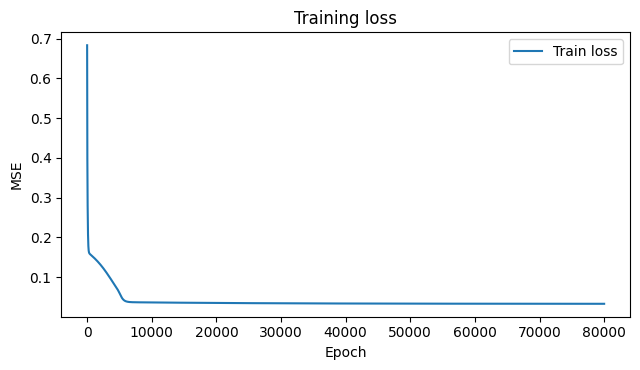

In [14]:
epochs = np.arange(1, len(train_losses) + 1)
plt.figure(figsize=(6.5, 3.8))
plt.plot(epochs, train_losses, label='Train loss')
plt.xlabel('Epoch')
plt.ylabel('MSE')
plt.title('Training loss')
plt.legend()
plt.tight_layout()
plt.show()

## 6) Function predictions over time

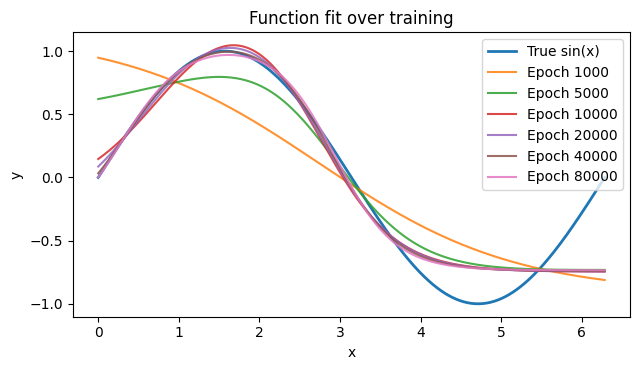

In [15]:
x_plot = torch.linspace(0.0, 2.0 * np.pi, 400).view(-1, 1)
y_true = torch.sin(x_plot).numpy()

plt.figure(figsize=(6.5, 3.8))
plt.plot(x_plot.numpy(), y_true, label='True sin(x)', linewidth=2)
for ep in snapshot_epochs:
    temp_model = SineMLP(hidden_dim=hidden_dim)
    temp_model.load_state_dict(snapshots[ep])
    temp_model.eval()
    with torch.no_grad():
        y_pred = temp_model(x_plot).numpy()
    plt.plot(x_plot.numpy(), y_pred, label=f'Epoch {ep}', alpha=0.85)

plt.xlabel('x')
plt.ylabel('y')
plt.title('Function fit over training')
plt.legend()
plt.tight_layout()
plt.show()

## 7) Unified dynamics overview

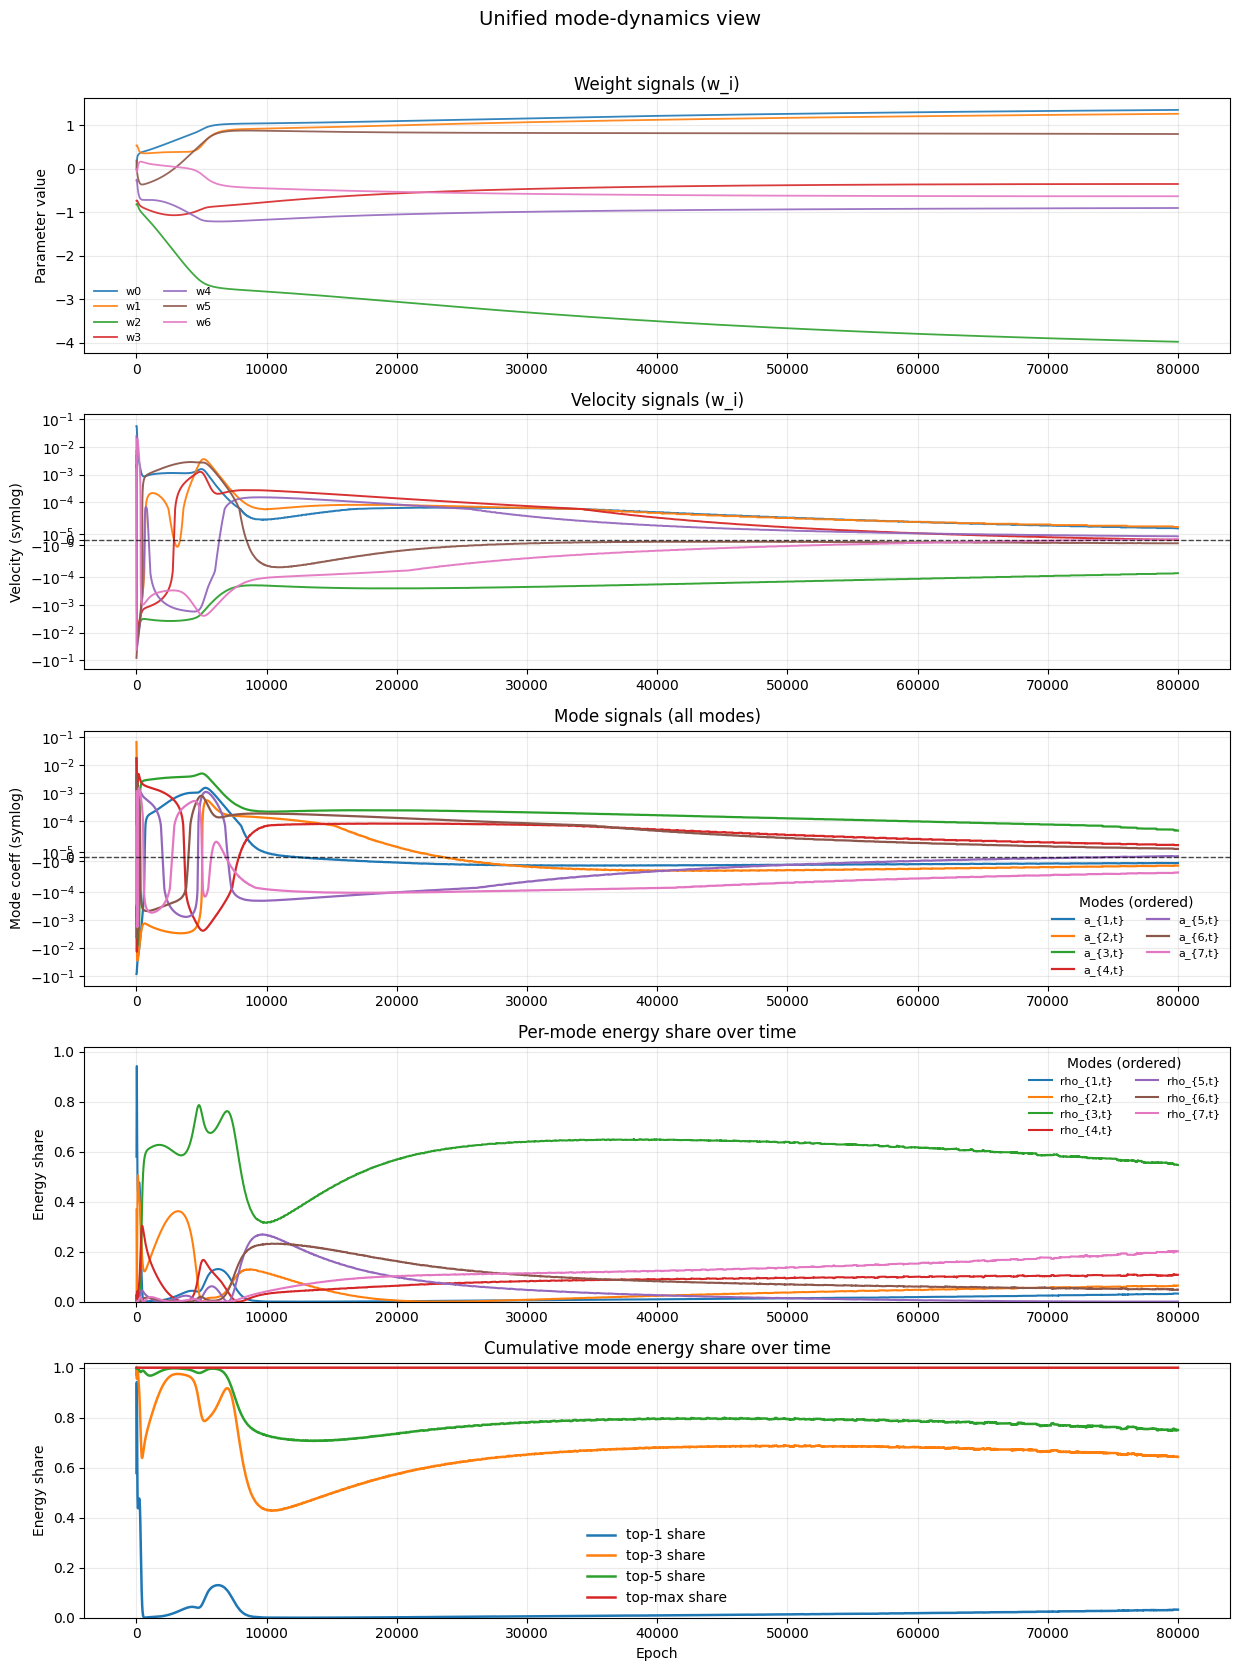

In [20]:
# Compute velocity matrix and mode coefficients
velocity_matrix = np.diff(weight_matrix, axis=0)  # shape: (num_checkpoints-1, num_params)
velocity_epochs = checkpoint_epochs[1:]

_u_time, _s_vals, vh_modes = np.linalg.svd(velocity_matrix, full_matrices=False)
n_modes = vh_modes.shape[0]
mode_coeffs_all = velocity_matrix @ vh_modes.T  # shape: (num_steps, n_modes)

# Mode energy share: rho_{k,t} = a_{k,t}^2 / sum_j a_{j,t}^2
energy_total = np.sum(mode_coeffs_all**2, axis=1) + 1e-12
rho_all = (mode_coeffs_all**2) / energy_total[:, None]

# Cumulative top-K shares (up to top-max)
k_candidates = [1, 3, 5, 10, n_modes]
k_values = []
for k in k_candidates:
    k_clamped = min(k, n_modes)
    if k_clamped not in k_values:
        k_values.append(k_clamped)

# Consistent color mapping for flattened coordinates w_i
n_weights = weight_matrix.shape[1]
weight_colors = {i: plt.cm.tab10(i % 10) for i in range(n_weights)}
weight_labels = {i: f'w{i}' for i in range(n_weights)}
mode_colors = [plt.cm.tab10(k % 10) for k in range(n_modes)]

fig, axes = plt.subplots(5, 1, figsize=(12.5, 17.0), sharex=False)

# (1) Weight signals
ax = axes[0]
for i in range(n_weights):
    ax.plot(
        checkpoint_epochs,
        weight_matrix[:, i],
        color=weight_colors[i],
        alpha=0.9,
        linewidth=1.3,
        label=weight_labels[i],
    )
ax.set_ylabel('Parameter value')
ax.set_title('Weight signals (w_i)')
ax.grid(alpha=0.25)
ax.legend(ncol=2, fontsize=8, frameon=False)

# (2) Velocity signals (symlog)
ax = axes[1]
for i in range(n_weights):
    ax.plot(
        velocity_epochs,
        velocity_matrix[:, i],
        color=weight_colors[i],
        alpha=0.95,
        linewidth=1.4,
    )
vel_linthresh = max(1e-6, np.quantile(np.abs(velocity_matrix), 0.60))
ax.set_yscale('symlog', linthresh=vel_linthresh, linscale=1.0, base=10)
ax.axhline(0.0, color='black', linestyle='--', linewidth=1.0, alpha=0.7)
ax.set_ylabel('Velocity (symlog)')
ax.set_title('Velocity signals (w_i)')
ax.grid(alpha=0.25, which='both')

# (3) Mode signals (all modes, color-coded)
ax = axes[2]
for k in range(n_modes):
    ax.plot(
        velocity_epochs,
        mode_coeffs_all[:, k],
        label=f'a_{{{k+1},t}}',
        linewidth=1.6,
        color=mode_colors[k],
    )
mode_linthresh = max(1e-8, np.quantile(np.abs(mode_coeffs_all), 0.60))
ax.set_yscale('symlog', linthresh=mode_linthresh, linscale=1.0, base=10)
ax.axhline(0.0, color='black', linestyle='--', linewidth=1.0, alpha=0.7)
ax.set_ylabel('Mode coeff (symlog)')
ax.set_title('Mode signals (all modes)')
ax.grid(alpha=0.25, which='both')
ax.legend(title='Modes (ordered)', ncol=2, fontsize=8, frameon=False)

# (4) Per-mode energy share signals
ax = axes[3]
for k in range(n_modes):
    ax.plot(
        velocity_epochs,
        rho_all[:, k],
        color=mode_colors[k],
        linewidth=1.5,
        label=f'rho_{{{k+1},t}}',
    )
ax.set_ylabel('Energy share')
ax.set_ylim(0.0, 1.02)
ax.set_title('Per-mode energy share over time')
ax.grid(alpha=0.25)
ax.legend(title='Modes (ordered)', ncol=2, fontsize=8, frameon=False)

# (5) Cumulative top-n energy share signals
ax = axes[4]
for k in k_values:
    share_k = np.sum(rho_all[:, :k], axis=1)
    label = f'top-{k} share' if k < n_modes else 'top-max share'
    ax.plot(velocity_epochs, share_k, linewidth=1.8, label=label)

ax.set_xlabel('Epoch')
ax.set_ylabel('Energy share')
ax.set_ylim(0.0, 1.02)
ax.set_title('Cumulative mode energy share over time')
ax.grid(alpha=0.25)
ax.legend(frameon=False)

fig.suptitle('Unified mode-dynamics view', fontsize=14)
fig.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()